# Objetivos
Construir el grafico con puntos fisicos



In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# == importar la libreria hecha ==
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), ".."))) # Añadir la ruta absoluta a 'mlpython/' al comienzo de sys.path
#import lib  

from lib import plot_branchings, physpoint, plot_branchings_and_lifetime

# ====

In [ ]:
# --- Paso 1: Crear un DataFrame de ejemplo con puntos físicos ---
# Columnas: m_phi, m12_2, positivity_ok, unitarity_ok, perturbativity_ok
df_read = pd.read_csv('./output/filtered_data_0.csv')

# --- Paso 2: Filtrar solo los puntos físicos donde positivity_ok, unitarity_ok y perturbativity_ok == 1 ---
df_physical = df_read[
    (df_read['positivity_ok'] == 1) &
    (df_read['unitarity_ok']  == 1) &
    (df_read['perturbativity_ok'] == 1)
].reset_index(drop=True)


print(len(df_physical))
df_physical.head()



0


,m_phi,m_A,sin_ba,tan_beta,lambda_6,lambda_7,m12_2,positivity_ok,unitarity_ok,perturbativity_ok,...,w_total_h2,w_total_top,branching_ratio_h2_gaga,lambda1,lambda2,lambda3,lambda4,lambda5,lambda6,lambda7


In [16]:
(df_physical["m_phi"] < 141).sum()

0

In [17]:
(df_physical[df_physical["m_phi"] < 200])

,m_phi,m_A,sin_ba,tan_beta,lambda_6,lambda_7,m12_2,positivity_ok,unitarity_ok,perturbativity_ok,...,w_total_h2,w_total_top,branching_ratio_h2_gaga,lambda1,lambda2,lambda3,lambda4,lambda5,lambda6,lambda7


In [18]:
df_physical.columns

Index(['m_phi', 'm_A', 'sin_ba', 'tan_beta', 'lambda_6', 'lambda_7', 'm12_2',
       'positivity_ok', 'unitarity_ok', 'perturbativity_ok', 'w_h2_bb',
       'w_h2_tautau', 'w_h2_uu', 'w_h2_du', 'w_h2_ln', 'w_h2_vv', 'w_h2_gaga',
       'w_h2_Zga', 'w_h2_gg', 'w_h2_hh', 'w_total_h2', 'w_total_top',
       'branching_ratio_h2_gaga', 'lambda1', 'lambda2', 'lambda3', 'lambda4',
       'lambda5', 'lambda6', 'lambda7'],
      dtype='object')

In [19]:
# Valores fijos (mismos que en physpoint y simulate_curve)
fixed_mA      = 300.0
fixed_sin_ba  = 1.0
fixed_tan_beta= 1e4
fixed_lambda6 = 0.1
fixed_lambda7 = 0.0

# Tolerancia para comparar con valores “exactos”
tol = 1e-3

# --- Paso 2: Filtrar por parámetros fijos dentro de la tolerancia ---
mask_fixed = (
    (df_physical['m_A'].sub(fixed_mA).abs()       < tol) &
    (df_physical['sin_ba'].sub(fixed_sin_ba).abs() < tol) &
    (df_physical['tan_beta'].sub(fixed_tan_beta).abs() < tol) &
    (df_physical['lambda_6'].sub(fixed_lambda6).abs() < tol) &
    (df_physical['lambda_7'].sub(fixed_lambda7).abs() < tol)
)

df_curve = df_physical.loc[mask_fixed].copy().reset_index(drop=True)

if df_curve.empty:
    raise RuntimeError(
        "No se encontraron filas que cumplan con los parámetros fijos. "
        "Revisa los valores o aumenta la tolerancia."
    )


print(f"Puntos tras filtrar por valores fijos: {len(df_curve)} filas.")
df_curve.head()


RuntimeError: No se encontraron filas que cumplan con los parámetros fijos. Revisa los valores o aumenta la tolerancia.

In [ ]:
# ==== extrae un valor de ejemplo =====
fixed_mphi = 200
mask_phi = df_physical['m_phi'].sub(fixed_mphi).abs() < 1
df_curve.loc[mask_phi].iloc[0]

m_phi                                                  300.0
m_A                                               300.000609
sin_ba                                                   1.0
tan_beta                                             10000.0
lambda_6                                                 0.1
lambda_7                                                 0.0
m12_2                                               8.999909
positivity_ok                                              1
unitarity_ok                                               1
perturbativity_ok                                          1
w_h2_bb                                                  0.0
w_h2_tautau                                              0.0
w_h2_uu                                                  0.0
w_h2_du                                                  0.0
w_h2_ln                                                  0.0
w_h2_vv                    [4.924940206773738e-10, 0.0, 0.0]
w_h2_gaga               

In [ ]:
# --- Paso 4: Ordenar por m_phi y extraer mphi / m12_2 ---
df_curve = df_curve.sort_values(by='m_phi').reset_index(drop=True)

# Vector de valores de m_phi (ordenados ascendentemente)
mphi_values = df_curve['m_phi'].to_numpy()

# Vector de valores de m12_2 correspondientes a cada m_phi
m12_values  = df_curve['m12_2'].to_numpy()


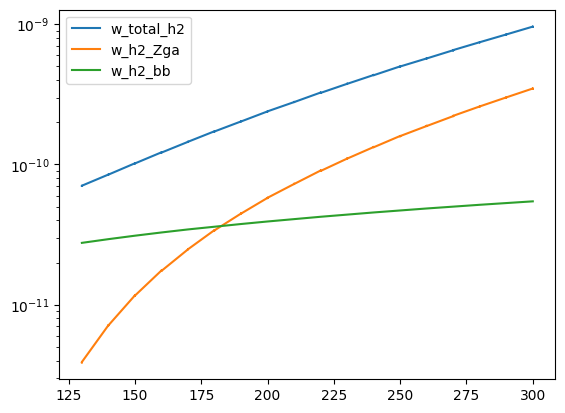

In [ ]:
plt.plot(df_curve["m_phi"],df_curve["w_total_h2"], label='w_total_h2')
plt.plot(df_curve["m_phi"],df_curve["w_h2_Zga"], label='w_h2_Zga')
plt.plot(df_curve["m_phi"],df_curve["w_h2_bb"], label='w_h2_bb')
plt.legend()
plt.yscale('log')
plt.show()


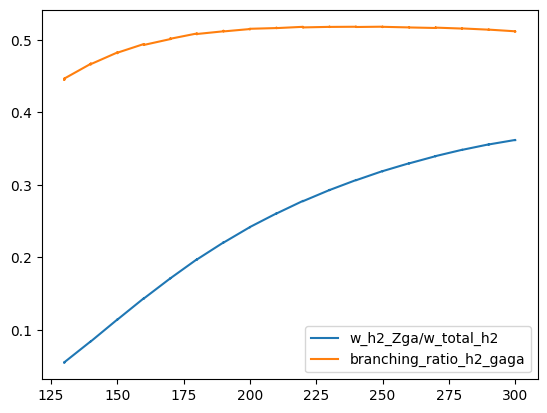

In [ ]:
plt.plot(df_curve["m_phi"],df_curve['w_h2_Zga'] / df_curve["w_total_h2"], label='w_h2_Zga/w_total_h2')
plt.plot(df_curve["m_phi"],df_curve['branching_ratio_h2_gaga'], label='branching_ratio_h2_gaga')
plt.legend()
# plt.yscale('log')
plt.show()

In [ ]:
# --- Paso 5: Empaquetar cada fila en el formato esperado por plot_branchings ---
results = []
for idx, row in df_curve.iterrows():
    # Extraer anchos y branching ratios
    total_w = row['w_total_h2']
    # Si total_width es cero o NaN, evitar división por cero
    if total_w is None or total_w == 0 or np.isnan(total_w):
        br_Zga = 0.0
        br_bb  = 0.0
    else:
        br_Zga = row['w_h2_Zga'] / total_w
        br_bb  = row['w_h2_bb'] / total_w

    entry = {
        'mphi': float(row['m_phi']),
        'br': {
            'gaga': float(row['branching_ratio_h2_gaga']),
            'Zga':  float(br_Zga),
            'bb':   float(br_bb)
        },
        'total_width': float(total_w),
        'flags': {
            'positivity':     int(row['positivity_ok']),
            'unitarity':      int(row['unitarity_ok']),
            'perturbativity': int(row['perturbativity_ok'])
        },
        'params': {
            'mA':       fixed_mA,
            'm12':      float(row['m12_2']),
            'lambda6':  fixed_lambda6,
            'lambda7':  fixed_lambda7,
            'sin_ba':   fixed_sin_ba,
            'tan_beta': fixed_tan_beta
        }
    }
    results.append(entry)


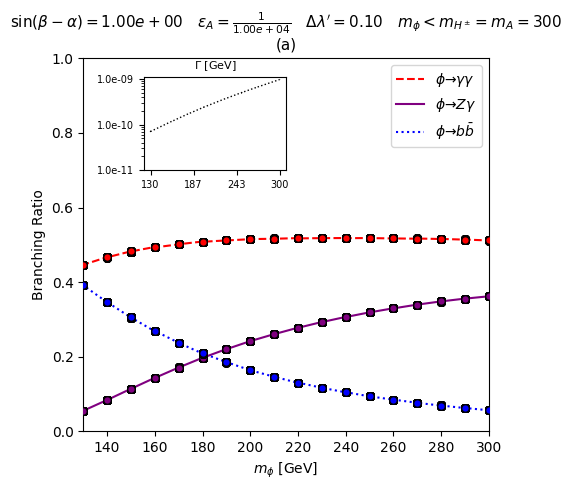

In [ ]:
# --- Paso 6: Graficar las branching ratios usando nuestro helper plot_branchings ---
plot_branchings(results, subplot_tag="(a)")


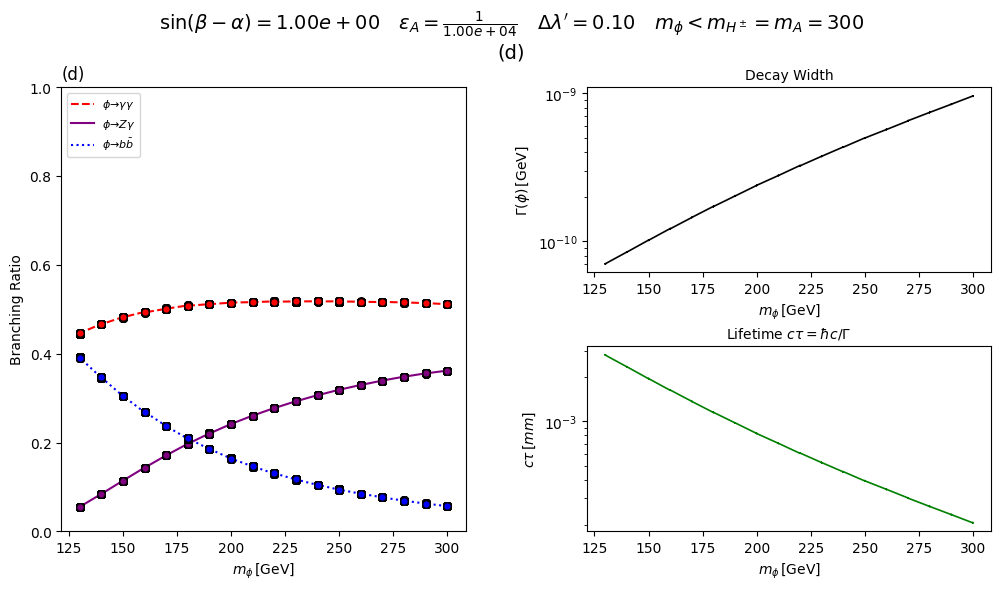

In [21]:
plot_branchings_and_lifetime(results,
    lifetime_unit="mm",
    lifetime_log=True,
    width_log=True
)